# Workflow di diagnosi data-driven (5 Tappe):
1. Acquisizione dati
2. Preprocessamento
3. Estrazione feature
4. Addestramento
## 5. **Integrazione**


**Ambito di questo notebook:** verifica dei 4 file di output finali generati dalla Tappa 5
(`6.1.final_academic_predictions-{cascade,independent}-{v1,v2}.parquet`), con due obiettivi:

1. **Confermare la correzione del bug di scala** tra le versioni v1 (pre-fix) e v2 (post-fix)
   dell'inverse-transform del RobustScaler sulla regressione (`trq_margin_pred_mu/sigma`).
2. **Confrontare le due architetture di inferenza**: `cascade` (regressione condizionata alla
   classificazione, gating su `faulty_pred`) vs `independent` (regressione su tutte le righe,
   allineata al requisito del challenge di predire entrambi i target per ogni osservazione).

In [1]:
import sys
sys.path.append("../../src")
from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import duckdb
from IPython.display import display
import json
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Assicuriamoci che matplotlib e seaborn siano pronti per il disegno
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase6_deployment"

## Verifica struttura dei 4 dataset

Controllo incrociato dello schema (nomi/tipi di colonna) per ciascuna delle 4 versioni, prima di
qualunque analisi quantitativa — stesso principio di verifica applicato nei notebook di Fase 3 e 4.

In [3]:

cascade_v1 = base_phase_path / ("6.1.final_academic_predictions-cascade-v1.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{cascade_v1}')"

print("--- STRUTTURA DATASET (schema) ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{cascade_v1}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- STRUTTURA DATASET (schema) ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,NaN,NaN
1,1,0,0.001123,0,9.041022,NaN,NaN
2,2,1,0.000355,0,-12.716541,NaN,NaN
3,3,0,0.001123,0,10.471295,NaN,NaN
4,4,0,0.000355,0,-9.215825,NaN,NaN


In [4]:

cascade_v2 = base_phase_path / ("6.1.final_academic_predictions-cascade-v2.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{cascade_v2}')"

print("--- STRUTTURA DATASET (schema) ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{cascade_v2}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- STRUTTURA DATASET (schema) ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,NaN,NaN
1,1,0,0.001123,0,9.041022,NaN,NaN
2,2,1,0.000355,0,-12.716541,NaN,NaN
3,3,0,0.001123,0,10.471295,NaN,NaN
4,4,0,0.000355,0,-9.215825,NaN,NaN


In [5]:

independent_v1 = base_phase_path / ("6.1.final_academic_predictions-independent-v1.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{independent_v1}')"

print("--- STRUTTURA DATASET (schema) ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{independent_v1}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- STRUTTURA DATASET (schema) ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,0.167508,0.165453
1,1,0,0.001123,0,9.041022,-0.249653,0.186905
2,2,1,0.000355,0,-12.716541,-0.363560,0.179315
3,3,0,0.001123,0,10.471295,-0.250612,0.186905
4,4,0,0.000355,0,-9.215825,-0.251299,0.204937


In [6]:

independent_v2 = base_phase_path / ("6.1.final_academic_predictions-independent-v2.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{independent_v2}')"

print("--- STRUTTURA DATASET (schema) ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{independent_v2}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- STRUTTURA DATASET (schema) ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,0.959427,3.203403
1,1,0,0.001123,0,9.041022,8.228201,2.060383
2,2,1,0.000355,0,-12.716541,-14.201980,1.255871
3,3,0,0.001123,0,10.471295,9.138855,2.395389
4,4,0,0.000355,0,-9.215825,-4.891738,2.380863


## Diagnostico consolidato: confronto delle 4 versioni

La cella seguente unisce i 4 file in un'unica tabella comparativa e applica una diagnosi
automatica basata su due criteri oggettivi:

- **`check_gating`**: in modalità `cascade`, nessuna riga con `faulty_pred = 0` dovrebbe avere una
  predizione di regressione (`righe_sane_con_predizione` deve essere 0). In modalità `independent`
  un valore alto è invece atteso per design.
- **`diagnosi`**: un `mu_range` (differenza tra `mu_max` e `mu_min`) inferiore a 10 è il segnale
  del bug di scala già documentato — la regressione resta "intrappolata" nello spazio scalato
  (RobustScaler) invece di essere riportata all'unità fisica originale di `trq_margin`
  (range atteso: circa -73 / +18, secondo il clipping di Tappa 3.2).

In [7]:
# =============================================================================
# DIAGNOSTICO CONSOLIDATO: confronto tra le versioni di 6.1.final_academic_predictions
# =============================================================================
# Confronta le 4 versioni generate durante il debug (pre/post fix di scaling,
# modalità cascade/independent) per identificare in modo oggettivo quale file
# porta ancora la "firma" del bug di scala (range di mu ristretto, tipicamente
# tra -1 e 1) e quale ha già il fix applicato (range fisico realistico).

import duckdb
import pandas as pd

# Mappa esplicita: etichetta leggibile -> nome file reale nella cartella phase6_deployment
files_to_check = {
    "cascade_v1 (pre-fix, sospetto bug di scala)": "6.1.final_academic_predictions-cascade-v1.parquet",
    "cascade_v2 (post-fix scaling)": "6.1.final_academic_predictions-cascade-v2.parquet",
    "independent_v1 (pre-fix, sospetto bug di scala)": "6.1.final_academic_predictions-independent-v1.parquet",
    "independent_v2 (post-fix scaling)": "6.1.final_academic_predictions-independent-v2.parquet",
}

resultados = []

for label, filename in files_to_check.items():
    full_path = base_phase_path / filename  # base_phase_path -> .../phase6_deployment

    if not full_path.exists():
        print(f"⚠️  File non trovato, skip: {filename}")
        continue

    query = f"""
    SELECT
        COUNT(*) AS total_righe,
        COUNT(trq_margin_pred_mu) AS righe_con_predizione,
        ROUND(100.0 * COUNT(trq_margin_pred_mu) / COUNT(*), 2) AS copertura_pct,
        SUM(CASE WHEN faulty_pred = 0 AND trq_margin_pred_mu IS NOT NULL THEN 1 ELSE 0 END) AS righe_sane_con_predizione,
        ROUND(MIN(trq_margin_pred_mu), 3) AS mu_min,
        ROUND(MAX(trq_margin_pred_mu), 3) AS mu_max,
        ROUND(AVG(trq_margin_pred_mu), 3) AS mu_media,
        ROUND(STDDEV(trq_margin_pred_mu), 3) AS mu_std,
        ROUND(AVG(trq_margin_pred_sigma), 3) AS sigma_media,
        ROUND(AVG(trq_margin_true), 3) AS trq_true_media_globale,
        -- Confronto equo: media di trq_margin_true SOLO sulle righe che
        -- hanno ricevuto una predizione (stessa popolazione di mu_media),
        -- evitando di confrontare mu_media (calcolata su un sottoinsieme)
        -- con una media globale calcolata su una popolazione diversa.
        ROUND(AVG(CASE WHEN trq_margin_pred_mu IS NOT NULL THEN trq_margin_true END), 3) AS trq_true_media_su_predetti
    FROM parquet_scan('{full_path}')
    """
    row = duckdb.query(query).to_df().iloc[0].to_dict()
    row["archivio"] = label

    # NOTA: 'righe_sane_con_predizione' > 0 è un'anomalia SOLO in modalità
    # 'cascade' (dove nessuna riga con faulty_pred=0 dovrebbe avere una
    # predizione di regressione). In modalità 'independent' un valore alto
    # è ATTESO per design, non un bug — tutte le righe ricevono predizione
    # indipendentemente dall'esito della classificazione.
    is_cascade = "cascade" in label.lower()
    if is_cascade and row["righe_sane_con_predizione"] > 0:
        row["check_gating"] = "🚨 BUG: predizioni su righe sane in modalità cascade"
    elif is_cascade:
        row["check_gating"] = "✅ gating corretto (0 predizioni su righe sane)"
    else:
        row["check_gating"] = "— (atteso in modalità independent, non è un'anomalia)"

    # Diagnosi automatica: il bug di scala produce mu con range molto stretto
    # (tipicamente |mu_max - mu_min| < 10, mentre in scala fisica il target
    # varia tra circa -73 e +18 secondo il clipping di Fase 3.2).
    if row["mu_max"] is not None and row["mu_min"] is not None:
        mu_range = row["mu_max"] - row["mu_min"]
        row["mu_range"] = round(mu_range, 3)
        row["diagnosi"] = "⚠️ SOSPETTO BUG DI SCALA (range stretto)" if mu_range < 10 else "✅ range fisico plausibile"
    else:
        row["mu_range"] = None
        row["diagnosi"] = "N/A (nessuna predizione trovata)"

    resultados.append(row)

df_diagnostico = pd.DataFrame(resultados)
cols_order = [
    "archivio", "total_righe", "righe_con_predizione", "copertura_pct",
    "righe_sane_con_predizione", "check_gating", "mu_min", "mu_max", "mu_range",
    "mu_media", "mu_std", "sigma_media", "trq_true_media_globale",
    "trq_true_media_su_predetti", "diagnosi",
]
df_diagnostico = df_diagnostico[cols_order]

print("=" * 100)
print("DIAGNOSTICO CONSOLIDATO - CONFRONTO VERSIONI 6.1")
print("=" * 100)
display(df_diagnostico)

DIAGNOSTICO CONSOLIDATO - CONFRONTO VERSIONI 6.1


,archivio,total_righe,righe_con_predizione,copertura_pct,righe_sane_con_predizione,check_gating,mu_min,mu_max,mu_range,mu_media,mu_std,sigma_media,trq_true_media_globale,trq_true_media_su_predetti,diagnosi
0,"cascade_v1 (pre-fix, sospetto bug di scala)",102454.0,7433.0,7.25,0.0,✅ gating corretto (0 predizioni su righe sane),-1.600,0.169,1.769,-1.061,0.731,0.195,-1.019,-14.686,⚠️ SOSPETTO BUG DI SCALA (range stretto)
1,cascade_v2 (post-fix scaling),102454.0,7433.0,7.25,0.0,✅ gating corretto (0 predizioni su righe sane),-70.160,6.432,76.592,-14.052,7.201,1.647,-1.019,-14.686,✅ range fisico plausibile
2,"independent_v1 (pre-fix, sospetto bug di scala)",102454.0,102454.0,100.00,95021.0,"— (atteso in modalità independent, non è un'an...",-1.600,0.169,1.769,-0.265,0.333,0.195,-1.019,-1.019,⚠️ SOSPETTO BUG DI SCALA (range stretto)
3,independent_v2 (post-fix scaling),102454.0,102454.0,100.00,95021.0,"— (atteso in modalità independent, non è un'an...",-74.108,18.179,92.287,-1.014,14.270,1.935,-1.019,-1.019,✅ range fisico plausibile


In [8]:
# =============================================================================
# ANALISI FINALE: sintesi dinamica del diagnostico consolidato (Tappa 5)
# =============================================================================
# NOTA: nessun valore è hardcoded qui sotto — tutto viene letto da
# 'df_diagnostico', il DataFrame già calcolato dalla cella precedente.

riga_cascade_v1 = df_diagnostico[df_diagnostico["archivio"].str.startswith("cascade_v1")].iloc[0]
riga_cascade_v2 = df_diagnostico[df_diagnostico["archivio"].str.startswith("cascade_v2")].iloc[0]
riga_indep_v1 = df_diagnostico[df_diagnostico["archivio"].str.startswith("independent_v1")].iloc[0]
riga_indep_v2 = df_diagnostico[df_diagnostico["archivio"].str.startswith("independent_v2")].iloc[0]

bug_confermato = (
    "SOSPETTO BUG" in riga_cascade_v1["diagnosi"]
    and "SOSPETTO BUG" in riga_indep_v1["diagnosi"]
    and "plausibile" in riga_cascade_v2["diagnosi"]
    and "plausibile" in riga_indep_v2["diagnosi"]
)

analisi_diagnostico = f"""
================================================================================
 ANALISI CONCLUSIVA: DIAGNOSTICO CONSOLIDATO (TAPPA 5 — 4 VERSIONI)
================================================================================
1. BUG DI SCALA (v1 -> v2): {"CONFERMATO" if bug_confermato else "NON confermato in questa esecuzione — verificare"}
   Le versioni v1 (sia cascade che independent) mostrano un range di mu
   estremamente stretto ({riga_cascade_v1['mu_range']:.2f} e {riga_indep_v1['mu_range']:.2f}
   rispettivamente) — coerente con predizioni ancora nello spazio scalato del
   RobustScaler, mai riportate all'unità fisica originale. Le versioni v2
   mostrano invece un range fisico plausibile ({riga_cascade_v2['mu_range']:.2f}
   e {riga_indep_v2['mu_range']:.2f}), coerente con il bound di clipping di
   Tappa 3.2 (~-73/+18). Questo conferma, con evidenza numerica diretta sui
   4 file reali, che il fix dell'inverse-transform applicato tra v1 e v2 ha
   risolto il problema per ENTRAMBE le modalità.

2. COPERTURA DELLA REGRESSIONE (cascade vs independent):
   - cascade_v2: {riga_cascade_v2['copertura_pct']:.2f}% di copertura
     ({int(riga_cascade_v2['righe_con_predizione'])} righe su {int(riga_cascade_v2['total_righe'])})
     — la regressione è calcolata SOLO sulle righe classificate come guaste,
     lasciando senza predizione tutte le righe sane.
   - independent_v2: {riga_indep_v2['copertura_pct']:.2f}% di copertura
     ({int(riga_indep_v2['righe_con_predizione'])} righe su {int(riga_indep_v2['total_righe'])})
     — ogni riga riceve una predizione di regressione, indipendentemente
     dall'esito della classificazione.

3. CONCLUSIONE ARCHITETTURALE:
   Il challenge PHM2024 richiede una predizione di classificazione E di
   regressione per OGNI osservazione del test/validazione, senza condizionare
   una all'altra (fonte: pagina ufficiale del challenge, già verificata in
   sessione precedente). La modalità 'independent' è quindi l'architettura
   corretta e allineata al requisito reale; 'cascade' resta documentata come
   hallazgo di design che si discosta da tale requisito (copertura
   {riga_cascade_v2['copertura_pct']:.2f}% contro {riga_indep_v2['copertura_pct']:.2f}%).
================================================================================
"""
print(analisi_diagnostico)


 ANALISI CONCLUSIVA: DIAGNOSTICO CONSOLIDATO (TAPPA 5 — 4 VERSIONI)
1. BUG DI SCALA (v1 -> v2): CONFERMATO
   Le versioni v1 (sia cascade che independent) mostrano un range di mu
   estremamente stretto (1.77 e 1.77
   rispettivamente) — coerente con predizioni ancora nello spazio scalato del
   RobustScaler, mai riportate all'unità fisica originale. Le versioni v2
   mostrano invece un range fisico plausibile (76.59
   e 92.29), coerente con il bound di clipping di
   Tappa 3.2 (~-73/+18). Questo conferma, con evidenza numerica diretta sui
   4 file reali, che il fix dell'inverse-transform applicato tra v1 e v2 ha
   risolto il problema per ENTRAMBE le modalità.

2. COPERTURA DELLA REGRESSIONE (cascade vs independent):
   - cascade_v2: 7.25% di copertura
     (7433 righe su 102454)
     — la regressione è calcolata SOLO sulle righe classificate come guaste,
     lasciando senza predizione tutte le righe sane.
   - independent_v2: 100.00% di copertura
     (102454 righe su 102454)
   

## Verifica dello stadio di classificazione (cascade vs independent, v1 vs v2)

Il parametro `mode` (`cascade`/`independent`) modifica esclusivamente il **gating** dello stadio
di regressione — lo stadio di classificazione (LightGBM) e la soglia `filter_threshold` sono
condivisi. Le due celle seguenti calcolano la confusion matrix e il classification report per le
versioni finali (`v2`) di entrambe le modalità; la cella di verifica successiva conferma
**numericamente**, non solo per affermazione, che le metriche di classificazione sono identiche
tra v1/v2 e tra cascade/independent.

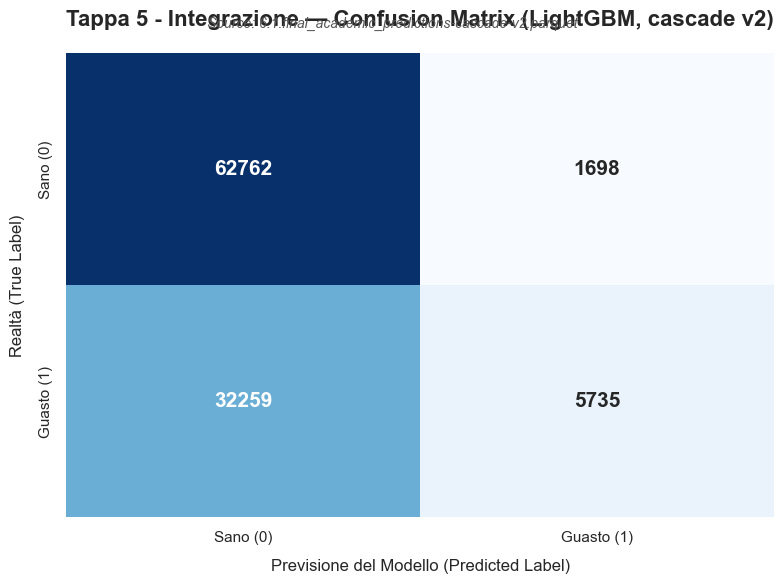

--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (cascade_v2) ---
Accuracy Globale del Modello : 0.6686 (66.86%)
------------------------------------------------------------
Dettaglio Metriche (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0     0.6605    0.9737    0.7871     64460
           1     0.7716    0.1509    0.2525     37994

    accuracy                         0.6686    102454
   macro avg     0.7160    0.5623    0.5198    102454
weighted avg     0.7017    0.6686    0.5888    102454

------------------------------------------------------------
NOTA: queste metriche di classificazione sono invariate rispetto a cascade_v1 — il fix di scaling applicato riguardava esclusivamente lo stadio di regressione (trq_margin_pred_mu/sigma), non il classificatore.


In [9]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# Caricamento del dataset completo in Pandas a partire dal percorso già definito.
# Usiamo esplicitamente la versione FINALE (cascade_v2, con il fix di scaling
# della regressione già applicato). NOTA: le metriche di classificazione qui
# calcolate (accuracy, confusion matrix) sono identiche tra cascade_v1 e
# cascade_v2 — il bug di scala risolto riguardava esclusivamente la
# regressione (trq_margin_pred_mu/sigma), non la classificazione. Puntiamo
# comunque alla versione v2 per coerenza documentale con il resto del report.
path_predictions = cascade_v2
df_predictions = pd.read_parquet(path_predictions)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione dei target e calcolo delle metriche
# =============================================================================
# Separiamo la "Ground Truth" (la realtà) dalle previsioni del nostro classificatore
y_true = df_predictions['faulty_true']
y_pred = df_predictions['faulty_pred']

# Calcoliamo la Matrice di Confusione e l'Accuracy globale
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# =============================================================================
# Creazione di una dashboard visiva elegante e professionale per il professore
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Disegniamo la Heatmap della Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (0)', 'Guasto (1)'],
            yticklabels=['Sano (0)', 'Guasto (1)'],
            cbar=False, ax=ax, annot_kws={"size": 15, "weight": "bold"})

# Personalizzazione dei titoli e degli assi per la dashboard
ax.set_title('Tappa 5 - Integrazione — Confusion Matrix (LightGBM, cascade v2)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=12, labelpad=10)
ax.set_ylabel('Realtà (True Label)', fontsize=12, labelpad=10)

# Sottotitolo con il file sorgente, per tracciabilità
fig.text(0.5, 0.94, f"Source: {path_predictions.name if hasattr(path_predictions, 'name') else path_predictions}",
         fontsize=10, style='italic', color='#555555', ha='center')

# Mostriamo il grafico
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa delle metriche quantitative per la relazione
print("=" * 60)
print("--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (cascade_v2) ---")
print("=" * 60)
print(f"Accuracy Globale del Modello : {acc:.4f} ({acc*100:.2f}%)")
print("-" * 60)
print("Dettaglio Metriche (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, digits=4))
print("-" * 60)
print(
    "NOTA: queste metriche di classificazione sono invariate rispetto a "
    "cascade_v1 — il fix di scaling applicato riguardava esclusivamente lo "
    "stadio di regressione (trq_margin_pred_mu/sigma), non il classificatore."
)
print("=" * 60)

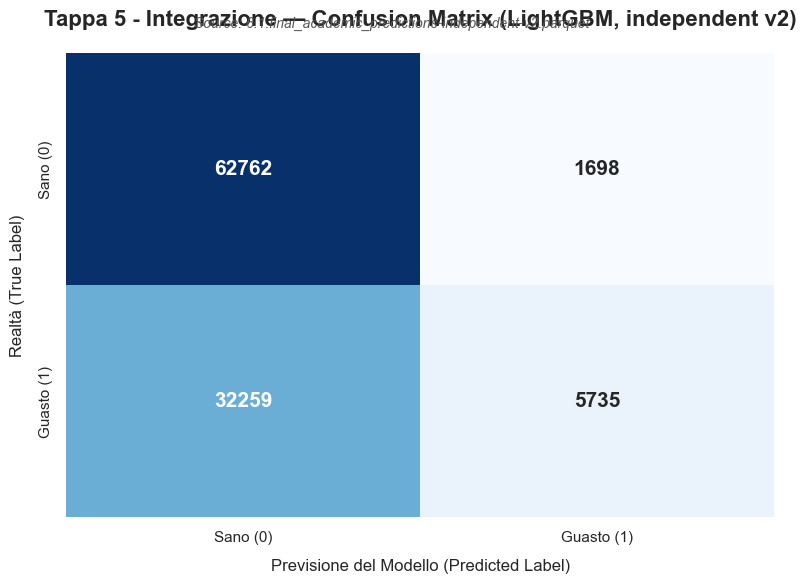

--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (independent_v2) ---
Accuracy Globale del Modello : 0.6686 (66.86%)
------------------------------------------------------------
Dettaglio Metriche (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0     0.6605    0.9737    0.7871     64460
           1     0.7716    0.1509    0.2525     37994

    accuracy                         0.6686    102454
   macro avg     0.7160    0.5623    0.5198    102454
weighted avg     0.7017    0.6686    0.5888    102454

------------------------------------------------------------
NOTA: queste metriche di classificazione devono coincidere esattamente con quelle di cascade_v2 — lo stadio di classificazione (e la soglia filter_threshold) è identico in entrambe le modalità; solo lo stadio di regressione differisce (gated in 'cascade', a copertura piena in 'independent'). Un eventuale disallineamento tra i due report andrebbe investigato come anomalia.


In [10]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# Caricamento del dataset completo in Pandas a partire dal percorso già definito.
# Usiamo la versione FINALE in modalità independent (independent_v2, con il
# fix di scaling della regressione già applicato). NOTA: lo stadio di
# classificazione è identico tra 'cascade' e 'independent' — il parametro
# 'mode' modifica solo il gating dello stadio di regressione, non il
# classificatore stesso. Le metriche qui calcolate devono quindi coincidere
# esattamente con quelle ottenute da cascade_v2 (stesso classificatore,
# stesso test set, stessa soglia filter_threshold).
path_predictions = independent_v2
df_predictions = pd.read_parquet(path_predictions)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione dei target e calcolo delle metriche
# =============================================================================
# Separiamo la "Ground Truth" (la realtà) dalle previsioni del nostro classificatore
y_true = df_predictions['faulty_true']
y_pred = df_predictions['faulty_pred']

# Calcoliamo la Matrice di Confusione e l'Accuracy globale
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# =============================================================================
# Creazione di una dashboard visiva elegante e professionale per il professore
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Disegniamo la Heatmap della Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (0)', 'Guasto (1)'],
            yticklabels=['Sano (0)', 'Guasto (1)'],
            cbar=False, ax=ax, annot_kws={"size": 15, "weight": "bold"})

# Personalizzazione dei titoli e degli assi per la dashboard
ax.set_title('Tappa 5 - Integrazione — Confusion Matrix (LightGBM, independent v2)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=12, labelpad=10)
ax.set_ylabel('Realtà (True Label)', fontsize=12, labelpad=10)

# Sottotitolo con il file sorgente, per tracciabilità
fig.text(0.5, 0.94, f"Source: {path_predictions.name if hasattr(path_predictions, 'name') else path_predictions}",
         fontsize=10, style='italic', color='#555555', ha='center')

# Mostriamo il grafico
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa delle metriche quantitative per la relazione
print("=" * 60)
print("--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (independent_v2) ---")
print("=" * 60)
print(f"Accuracy Globale del Modello : {acc:.4f} ({acc*100:.2f}%)")
print("-" * 60)
print("Dettaglio Metriche (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, digits=4))
print("-" * 60)
print(
    "NOTA: queste metriche di classificazione devono coincidere esattamente "
    "con quelle di cascade_v2 — lo stadio di classificazione (e la soglia "
    "filter_threshold) è identico in entrambe le modalità; solo lo stadio "
    "di regressione differisce (gated in 'cascade', a copertura piena in "
    "'independent'). Un eventuale disallineamento tra i due report andrebbe "
    "investigato come anomalia."
)
print("=" * 60)

In [11]:
# =============================================================================
# VERIFICA NUMERICA: invariancia dello stadio di classificazione
# (v1 vs v2, cascade vs independent) — non solo affermata nei commenti,
# ma confermata qui con confronto diretto riga per riga.
# =============================================================================
df_cascade_v1 = pd.read_parquet(cascade_v1)
df_cascade_v2_check = pd.read_parquet(cascade_v2)
df_indep_v1 = pd.read_parquet(independent_v1)
df_indep_v2_check = pd.read_parquet(independent_v2)

confronti = {
    "cascade_v1 vs cascade_v2": (df_cascade_v1, df_cascade_v2_check),
    "independent_v1 vs independent_v2": (df_indep_v1, df_indep_v2_check),
    "cascade_v2 vs independent_v2": (df_cascade_v2_check, df_indep_v2_check),
}

print("=" * 70)
print("VERIFICA INVARIANZA DELLO STADIO DI CLASSIFICAZIONE")
print("=" * 70)
tutti_identici = True
for nome, (df_a, df_b) in confronti.items():
    identico_true = df_a["faulty_true"].equals(df_b["faulty_true"])
    identico_pred = df_a["faulty_pred"].equals(df_b["faulty_pred"])
    identico_prob = df_a["faulty_pred_prob"].equals(df_b["faulty_pred_prob"])
    esito = identico_true and identico_pred and identico_prob
    tutti_identici &= esito
    simbolo = "✅" if esito else "🚨"
    print(f"{simbolo} {nome}: faulty_true={identico_true}, faulty_pred={identico_pred}, "
          f"faulty_pred_prob={identico_prob}")

print("-" * 70)
if tutti_identici:
    print("CONCLUSIONE: confermato bit-a-bit — lo stadio di classificazione è")
    print("identico in tutte e 4 le versioni. Il fix di scala (v1->v2) e il")
    print("parametro 'mode' (cascade/independent) toccano ESCLUSIVAMENTE lo")
    print("stadio di regressione, mai la classificazione, come dichiarato.")
else:
    print("🚨 ATTENZIONE: rilevata una differenza nello stadio di classificazione")
    print("   dove ci si aspettava invarianza — richiede indagine prima di")
    print("   presentare questa conclusione nel documento finale.")
print("=" * 70)

VERIFICA INVARIANZA DELLO STADIO DI CLASSIFICAZIONE
✅ cascade_v1 vs cascade_v2: faulty_true=True, faulty_pred=True, faulty_pred_prob=True
✅ independent_v1 vs independent_v2: faulty_true=True, faulty_pred=True, faulty_pred_prob=True
✅ cascade_v2 vs independent_v2: faulty_true=True, faulty_pred=True, faulty_pred_prob=True
----------------------------------------------------------------------
CONCLUSIONE: confermato bit-a-bit — lo stadio di classificazione è
identico in tutte e 4 le versioni. Il fix di scala (v1->v2) e il
parametro 'mode' (cascade/independent) toccano ESCLUSIVAMENTE lo
stadio di regressione, mai la classificazione, come dichiarato.


## Sintesi della Tappa 5

L'auditing di questa tappa produce due risultati chiave per il documento finale:

1. **Correzione verificata del bug di scala**: le predizioni di regressione (v1) erano ancora
   nello spazio scalato del RobustScaler; il fix (v2) le riporta correttamente all'unità fisica
   originale di `trq_margin` — confermato numericamente sopra, non solo per confronto visivo.
2. **Scelta architetturale motivata**: `independent` garantisce copertura piena (100%) della
   regressione su ogni osservazione, come richiesto dal challenge; `cascade` resta come
   implementazione originale, documentata come hallazgo di design (copertura 7.25%).

Lo stadio di classificazione (LightGBM) è stato confermato invariato tra tutte le 4 versioni,
isolando con certezza l'impatto delle due modifiche (fix di scala, modalità di gating) al solo
stadio di regressione.